<a href="https://colab.research.google.com/github/afllaabdi/tugas_NLP/blob/main/Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Optional WordCloud
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except:
    WORDCLOUD_AVAILABLE = False

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# LOAD DATA
# =========================
file_path = '/content/drive/MyDrive/dataset/dataset_pangan.csv'

df = pd.read_csv(file_path)
df = df.rename(columns={'Content': 'text'})

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (964, 1)


,text
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d..."
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi..."
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J..."


In [ ]:
# =========================
# DATA CLEANING
# =========================
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus simbol & angka
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_text)

df[['text', 'clean_text']].head(30)

,text,clean_text
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...,ferry irwandi cicip aldis burger dan daftar ma...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d...",harga sembako jatim terbaru gas naik cabai dan...
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi...",aceh alami inflasi pada maret tertinggi di ac...
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...,video komisi iv dpr ungkap biang kerok harga b...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J...",maret inflasi harga ayam hingga telur jadi pe...
5,"Harga Sembako Jawa Timur 1 April 2025, Minyak ...",harga sembako jawa timur april minyak curah ...
6,"Panen Raya Lebih Awal, Kuningan Jaga Pasokan B...",panen raya lebih awal kuningan jaga pasokan beras
7,GPM Tasikmalaya Sediakan Pangan Murah Jelang R...,gpm tasikmalaya sediakan pangan murah jelang r...
8,Jeritan UMKM Cirebon Akibat Harga Tepung Beras...,jeritan umkm cirebon akibat harga tepung beras...
9,"Harga Sembako Hari Ini 31 Maret 2026, Harga Da...",harga sembako hari ini maret harga daging ay...


In [ ]:
# =========================
# BEFORE NORMALIZATION
# =========================
df['before_norm'] = df['clean_text']

# =========================
# NORMALIZATION (STOPWORD)
# =========================
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()
df['clean_text'] = df['clean_text'].apply(stopword.remove)

# =========================
# COMPARE BEFORE vs AFTER
# =========================
compare = df[['before_norm', 'clean_text']].head(10)
compare

df.head(30)

,text,clean_text,before_norm
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...,ferry irwandi cicip aldis burger daftar makana...,ferry irwandi cicip aldis burger dan daftar ma...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d...",harga sembako jatim terbaru gas naik cabai dag...,harga sembako jatim terbaru gas naik cabai dan...
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi...",aceh alami inflasi maret tertinggi aceh tengah,aceh alami inflasi pada maret tertinggi di ac...
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...,video komisi iv dpr ungkap biang kerok harga b...,video komisi iv dpr ungkap biang kerok harga b...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J...",maret inflasi harga ayam hingga telur jadi pe...,maret inflasi harga ayam hingga telur jadi pe...
5,"Harga Sembako Jawa Timur 1 April 2025, Minyak ...",harga sembako jawa timur april minyak curah ...,harga sembako jawa timur april minyak curah ...
6,"Panen Raya Lebih Awal, Kuningan Jaga Pasokan B...",panen raya lebih awal kuningan jaga pasokan beras,panen raya lebih awal kuningan jaga pasokan beras
7,GPM Tasikmalaya Sediakan Pangan Murah Jelang R...,gpm tasikmalaya sediakan pangan murah jelang r...,gpm tasikmalaya sediakan pangan murah jelang r...
8,Jeritan UMKM Cirebon Akibat Harga Tepung Beras...,jeritan umkm cirebon akibat harga tepung beras...,jeritan umkm cirebon akibat harga tepung beras...
9,"Harga Sembako Hari Ini 31 Maret 2026, Harga Da...",harga sembako hari maret harga daging ayam t...,harga sembako hari ini maret harga daging ay...


In [ ]:
# =========================
# DATA REDUCTION
# =========================
print("Jumlah data sebelum reduction:", df.shape)
print("Jumlah duplikat:", df.duplicated().sum())

df.head(10)
df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah data setelah reduction:", df.shape)

df.head(10)

Jumlah data sebelum reduction: (964, 2)
Jumlah duplikat: 232
Jumlah data setelah reduction: (732, 2)


,text,clean_text
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...,ferry irwandi cicip aldis burger daftar makana...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d...",harga sembako jatim terbaru gas naik cabai dag...
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi...",aceh alami inflasi maret tertinggi aceh tengah
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...,video komisi iv dpr ungkap biang kerok harga b...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J...",maret inflasi harga ayam hingga telur jadi pe...
5,"Harga Sembako Jawa Timur 1 April 2025, Minyak ...",harga sembako jawa timur april minyak curah ...
6,"Panen Raya Lebih Awal, Kuningan Jaga Pasokan B...",panen raya lebih awal kuningan jaga pasokan beras
7,GPM Tasikmalaya Sediakan Pangan Murah Jelang R...,gpm tasikmalaya sediakan pangan murah jelang r...
8,Jeritan UMKM Cirebon Akibat Harga Tepung Beras...,jeritan umkm cirebon akibat harga tepung beras...
9,"Harga Sembako Hari Ini 31 Maret 2026, Harga Da...",harga sembako hari maret harga daging ayam t...


In [ ]:
# =========================
# FEATURE ENGINEERING (TEXT LENGTH)
# =========================
df['text_length'] = df['clean_text'].apply(len)

df[['clean_text', 'text_length']].head()

,clean_text,text_length
0,ferry irwandi cicip aldis burger daftar makana...,65
1,harga sembako jatim terbaru gas naik cabai dag...,60
2,aceh alami inflasi maret tertinggi aceh tengah,47
3,video komisi iv dpr ungkap biang kerok harga b...,55
4,maret inflasi harga ayam hingga telur jadi pe...,50


In [ ]:
# =========================
# SAVE DATA
file_save_path = '/content/drive/MyDrive/dataset/dataset_pangan_hasil.csv'

df.to_csv(file_save_path, index=False)

print("Dataset berhasil disimpan!")

NameError: name 'df' is not defined

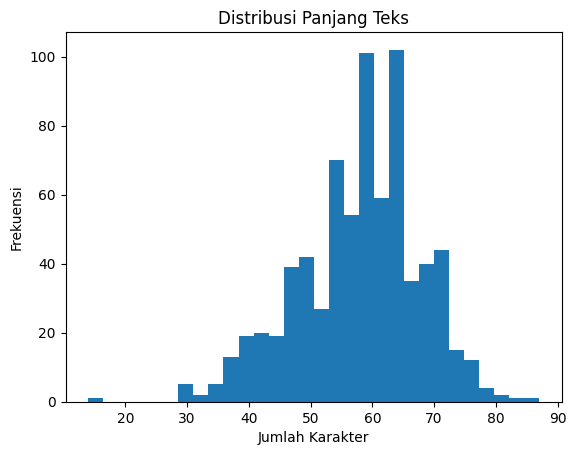

In [ ]:
# =========================
# DISTRIBUSI PANJANG TEKS
# =========================
plt.hist(df['text_length'], bins=30)
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()